   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Número de amostras: 150
Número de características: 4


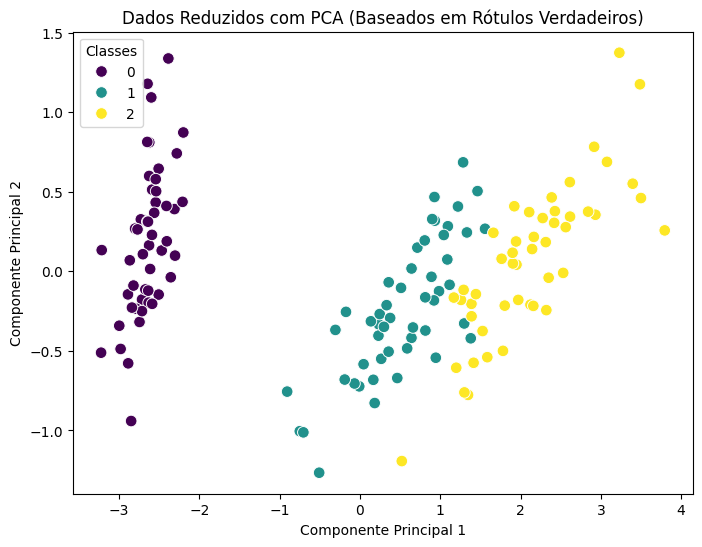

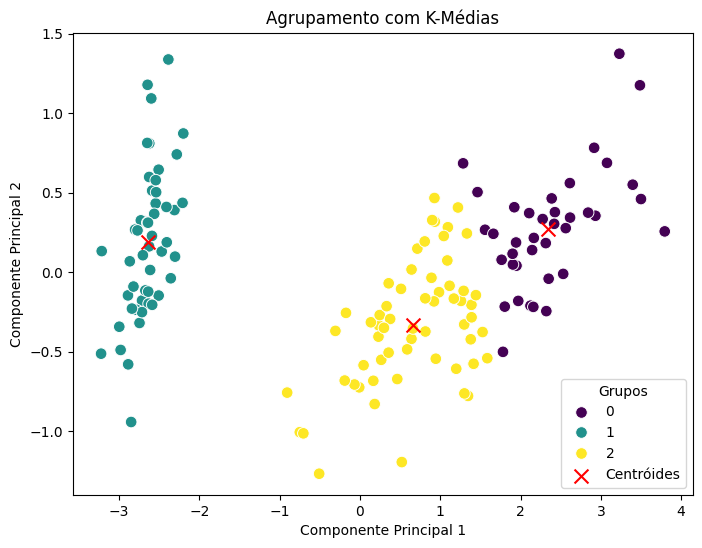

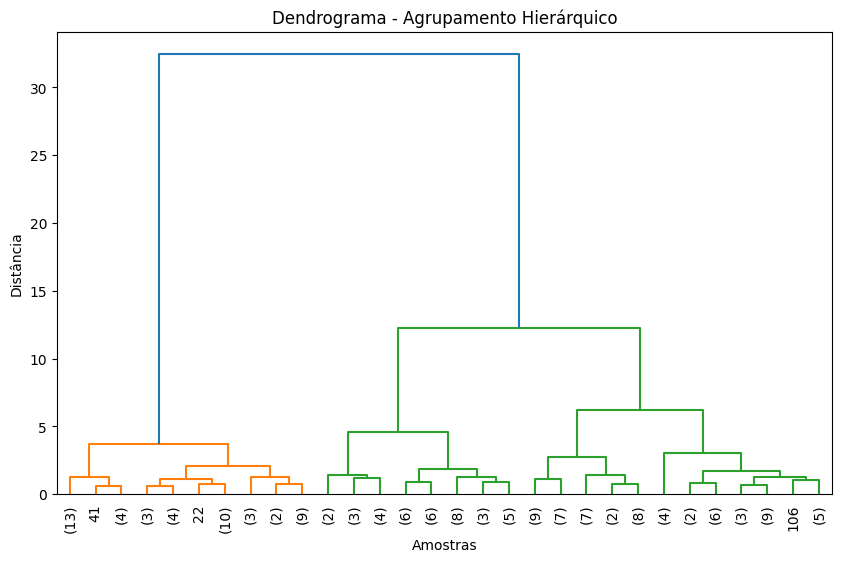

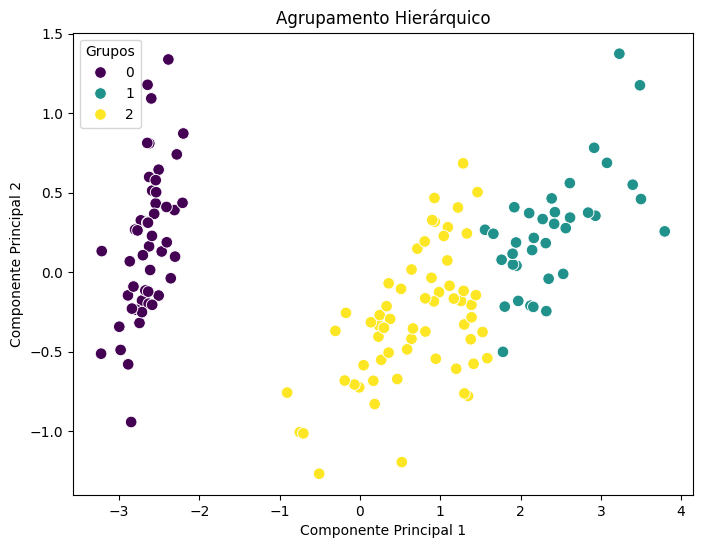

Índice Randômico Ajustado (ARI):
K-Médias: 0.716
Agrupamento Hierárquico: 0.745
O método Hierárquico apresentou um desempenho mais próximo dos rótulos reais.


In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

# Passo 1: Importação dos dados
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # Apenas para comparação futura

# Exibir informações básicas
print(X.head())
print("Número de amostras:", X.shape[0])
print("Número de características:", X.shape[1])

# Passo 2: Redução de Dimensionalidade com PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plotando os dados em 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', s=70)
plt.title("Dados Reduzidos com PCA (Baseados em Rótulos Verdadeiros)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Classes")
plt.show()

# Passo 3: Agrupamento com K-Médias
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

# Plotando os agrupamentos do K-Médias
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', s=70)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x', s=100, label='Centróides')
plt.title("Agrupamento com K-Médias")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Grupos")
plt.show()

# Passo 4: Agrupamento Hierárquico
linkage_matrix = linkage(X_pca, method='ward')

# Gerando o dendrograma
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrograma - Agrupamento Hierárquico")
plt.xlabel("Amostras")
plt.ylabel("Distância")
plt.show()

# Dividindo os dados em 3 grupos
hierarchical_labels = fcluster(linkage_matrix, t=3, criterion='maxclust') - 1  # Ajustar para começar do índice 0

# Plotando os agrupamentos hierárquicos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=hierarchical_labels, palette='viridis', s=70)
plt.title("Agrupamento Hierárquico")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Grupos")
plt.show()

# Passo 5: Comparação entre os métodos
ari_kmeans = adjusted_rand_score(y, kmeans_labels)
ari_hierarchical = adjusted_rand_score(y, hierarchical_labels)

print("Índice Randômico Ajustado (ARI):")
print(f"K-Médias: {ari_kmeans:.3f}")
print(f"Agrupamento Hierárquico: {ari_hierarchical:.3f}")

# Discussão
if ari_kmeans > ari_hierarchical:
    print("O método K-Médias apresentou um desempenho mais próximo dos rótulos reais.")
elif ari_kmeans < ari_hierarchical:
    print("O método Hierárquico apresentou um desempenho mais próximo dos rótulos reais.")
else:
    print("Ambos os métodos apresentaram desempenho similar.")
